# 015 — Supplementary Tables and Figures

Produces all supplementary material for the lncRNA classifier benchmark paper.

## Contents

| Item | Function | Output |
|------|----------|--------|
| T1 | `build_cv_metrics_table` | Full CV metrics — long format |
| T2 | `build_per_fold_metrics_table` | Wide balanced-accuracy summary |
| T3 | `build_shap_importance_table` | All-feature SHAP importance |
| T4 | `build_stat_tests_table` | MWU + chi2 tests (entropy stratification) |
| T5 | `build_calibration_metrics_table` | ECE / MCE per tool |
| F1 | `plot_roc_curves` | Per-tool ROC curves |
| F2 | `plot_confusion_matrices` | Normalised confusion matrices |
| F3 | `plot_probability_distributions` | Score distributions by true class |
| F4 | `plot_tool_entropy_distributions` | Per-tool H(p) entropy distributions |
| F5 | `plot_calibration_curves` | Per-tool reliability curves with ECE/MCE |
| F6 | `plot_entropy_by_class` | H_pred histogram — PC vs lncRNA |
| F7 | `plot_accuracy_vs_threshold` (strategy 1) | Balanced accuracy vs threshold (overall) |
| F8 | `plot_accuracy_vs_threshold` (strategy 2) | Balanced accuracy vs threshold (per class) |
| F9 | `plot_feature_correlation_heatmap` | Feature correlation heatmap |
| F10 | `plot_feature_dendrogram` | Feature hierarchical dendrogram |

## Imports

In [ ]:
import sys
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

warnings.filterwarnings("ignore")

# Silence matplotlib font warnings
logging.getLogger("matplotlib").setLevel(logging.ERROR)
logging.getLogger("fontTools").setLevel(logging.ERROR)

sys.path.insert(0, "/mnt/cbib/LNClassifier/paper/workflow")

from utils.entropy import load_dataset, load_additional_features
from utils.features import (
    filter_feature_columns,
    get_categorical_and_continuous_columns,
    get_probabilities,
)
from utils.parsing import load_tables
from utils.stats import run_stat_tests
from utils.supplementary import (
    # data loading
    load_fold_binary_tables,
    # tables
    build_cv_metrics_table,
    build_per_fold_metrics_table,
    build_shap_importance_table,
    build_per_fold_shap_table,
    build_stat_tests_table,
    build_calibration_metrics_table,
    # figures — performance
    plot_roc_curves,
    plot_confusion_matrices,
    plot_probability_distributions,
    plot_tool_entropy_distributions,
    plot_calibration_curves,
    # figures — ensemble entropy
    plot_entropy_by_class,
    compute_accuracy_vs_threshold,
    plot_accuracy_vs_threshold,
    # figures — features
    plot_feature_correlation_heatmap,
    plot_feature_dendrogram,
    # export
    save_table,
    build_supplementary_workbook,
)

np.random.seed(42)
print("Imports OK")

Imports OK


## Config

In [ ]:
BASE    = Path("/mnt/cbib/LNClassifier/paper")
DATASET = "gencode.v47.common.cdhit.cv"
N_FOLDS = 5

RESULTS_DIR  = BASE / "results"
DATASET_DIR  = RESULTS_DIR / DATASET
SHAP_DIR     = DATASET_DIR / "features" / "shap_clustered"
CLUSTER_CSV  = DATASET_DIR / "features" / "clustering" / "feature_clusters_at_distances.csv"
ENTROPY_TSV  = DATASET_DIR / "features" / "entropy" / f"{DATASET}_uncertainty_analysis.tsv"

# Output directories
FIG_DIR   = DATASET_DIR / "figures" / "supplementary"
TABLE_DIR = DATASET_DIR / "supplementary_tables" / "classifier"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset   : {DATASET}")
print(f"Figures   : {FIG_DIR}")
print(f"Tables    : {TABLE_DIR}")

Dataset   : gencode.v47.common.cdhit.cv
Figures   : /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/figures/supplementary
Tables    : /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/supplementary_tables/classifier


## Data Loading

In [ ]:
# ── Main dataset (probs + labels + features) ──────────────────────────────────
data = load_dataset(DATASET)
probs   = data["probs"]    # tool probability columns (noncoding already inverted)
labels  = data["labels"]   # coding_class (1/0), biotype
features_df = data["features"]
binary_raw  = data["binary"]

print(f"\nprobs   : {probs.shape}")
print(f"labels  : {labels.shape}")
print(f"features: {features_df.shape}")
print(f"binary  : {binary_raw.shape}")

Extracted 8 probability columns.
Inverting noncoding probabilities...
  - Inverting column: Noncoding_prob_ss_lncDC

probs   : (111652, 8)
labels  : (111652, 2)
features: (111652, 172)
binary  : (111652, 13)


In [ ]:
# ── Per-fold binary tables ─────────────────────────────────────────────────────
cv_dfs = load_fold_binary_tables(RESULTS_DIR, DATASET, N_FOLDS)

  Loaded fold1: 22,346 transcripts
  Loaded fold2: 22,321 transcripts
  Loaded fold3: 22,334 transcripts
  Loaded fold4: 22,332 transcripts
  Loaded fold5: 22,319 transcripts
Total folds loaded: 5


In [ ]:
# ── Continuous and categorical feature split ───────────────────────────────────
feat_cols = filter_feature_columns(features_df)
features_filtered = features_df[feat_cols]
cat_cols, cont_cols = get_categorical_and_continuous_columns(features_filtered)
print(f"Continuous: {len(cont_cols)}  |  Categorical: {len(cat_cols)}")

scalar      = features_filtered[cont_cols]
categorical = features_filtered[cat_cols]

Identified length columns to exclude: ['Transcript_length_lncDC', 'length_plncpro'] (keeping RNA_size_feelnc for reference)
Total number of columns in features table: 172
Number of kept feature columns: 128
Feature columns: ['kmerScore_1mer_feelnc', 'kmerScore_2mer_feelnc', 'kmerScore_3mer_feelnc', 'kmerScore_6mer_feelnc', 'kmerScore_9mer_feelnc', 'kmerScore_12mer_feelnc', 'ORF_cover_feelnc', 'RNA_size_feelnc', 'ORF_l_cpat', 'Fickett_l_cpat', 'Hexamer_l_cpat', 'ORF_coverage_l_cpat', 'GC_content_lncDC', 'Fickett_score_lncDC', 'ORF_T0_length_lncDC', 'ORF_T1_length_lncDC', 'ORF_T2_length_lncDC', 'ORF_T0_coverage_lncDC', 'ORF_T1_coverage_lncDC', 'ORF_T3_coverage_lncDC', 'Hexamer_score_ORF_T0_lncDC', 'Hexamer_score_ORF_T1_lncDC', 'Hexamer_score_ORF_T2_lncDC', 'Hexamer_score_ORF_T3_lncDC', 'RCB_T0_lncDC', 'RCB_T1_lncDC', 'ORF_T0_PI_lncDC', 'ORF_T0_MW_lncDC', 'ORF_T0_aromaticity_lncDC', 'ORF_T0_instability_lncDC', 'ORF_T1_MW_lncDC', 'ORF_T1_instability_lncDC', 'ORF_T2_MW_lncDC', 'ORF_T3_MW_ln

In [ ]:
# ── Entropy groups for stat-test tables (optional — skip if file absent) ───────
entropy_available = ENTROPY_TSV.exists()
cluster_available = CLUSTER_CSV.exists()
shap_available    = (SHAP_DIR / "shap_aggregated.csv").exists()

print(f"Entropy TSV   : {'OK' if entropy_available else 'NOT FOUND — T4 will be skipped'}")
print(f"Cluster CSV   : {'OK' if cluster_available else 'NOT FOUND'}")
print(f"SHAP artefacts: {'OK' if shap_available    else 'NOT FOUND — T3/T3b will be skipped'}")

Entropy TSV   : OK
Cluster CSV   : OK
SHAP artefacts: OK


---
## T1 — Full CV Metrics (long format)

In [ ]:
t1 = build_cv_metrics_table(cv_dfs)
display(t1)
save_table(t1, TABLE_DIR / "T1_cv_metrics_long.tsv", index=False)

,fold,tool,accuracy,balanced_accuracy,precision,recall,f1_score
0,fold1,CPAT,0.7799,0.7421,0.8076,0.7421,0.7511
1,fold2,CPAT,0.7824,0.7451,0.8096,0.7451,0.7543
2,fold3,CPAT,0.7799,0.7429,0.8053,0.7429,0.7519
3,fold4,CPAT,0.7816,0.7454,0.8064,0.7454,0.7544
4,fold5,CPAT,0.7759,0.7378,0.8031,0.7378,0.7464
5,fold1,FEELnc,0.9135,0.9131,0.9088,0.9131,0.9107
6,fold2,FEELnc,0.9177,0.9184,0.9129,0.9184,0.9153
7,fold3,FEELnc,0.9166,0.9170,0.9118,0.9170,0.9141
8,fold4,FEELnc,0.9172,0.9172,0.9125,0.9172,0.9146
9,fold5,FEELnc,0.9155,0.9159,0.9107,0.9159,0.9129


  Saved -> T1_cv_metrics_long.tsv  (40 rows x 7 cols)


---
## T2 — Per-fold Balanced Accuracy Summary (wide format)

In [ ]:
t2 = build_per_fold_metrics_table(cv_dfs, metric="balanced_accuracy")
display(t2)
save_table(t2, TABLE_DIR / "T2_balanced_accuracy_per_fold.tsv")

,fold1,fold2,fold3,fold4,fold5,Mean,Std
Tool,,,,,,,
lncRNABERT,0.9503,0.9486,0.9506,0.9492,0.9513,0.9500,0.0010
PlncPro,0.9311,0.9309,0.9320,0.9307,0.9317,0.9313,0.0005
mRNN,0.9229,0.9235,0.9225,0.9240,0.9207,0.9227,0.0011
FEELnc,0.9131,0.9184,0.9170,0.9172,0.9159,0.9163,0.0018
RNAsamba,0.9141,0.9166,0.9157,0.9156,0.9162,0.9156,0.0009
LncFinder,0.8974,0.9035,0.9036,0.9043,0.9014,0.9020,0.0025
LncDC,0.8371,0.8350,0.8389,0.8376,0.8339,0.8365,0.0018
CPAT,0.7421,0.7451,0.7429,0.7454,0.7378,0.7427,0.0027


  Saved -> T2_balanced_accuracy_per_fold.tsv  (8 rows x 7 cols)


---
## T3 — SHAP Feature Importance

In [ ]:
if shap_available:
    t3 = build_shap_importance_table(SHAP_DIR)
    display(t3.head(20))
    save_table(t3, TABLE_DIR / "T3_shap_importance_all_features.tsv")

    t3b = build_per_fold_shap_table(SHAP_DIR)
    display(t3b.head(10))
    save_table(t3b, TABLE_DIR / "T3b_shap_per_fold.tsv")
else:
    print("SHAP artefacts not found — skipping T3/T3b")

,label,mean_abs_shap,std_abs_shap,fold1,fold2,fold3,fold4,fold5
all_Bitscore_plncpro,Sum of BLAST hit bitscores,0.104179,0.002914,0.108121,0.101177,0.103179,0.106261,0.102157
kmerScore_12mer_feelnc,12-mer k-mer score,0.059201,0.003462,0.062637,0.058467,0.053650,0.061221,0.060031
ORF.Max.Len_lncfinder,Max. ORF length,0.042113,0.001738,0.043802,0.040446,0.041966,0.040383,0.043969
ORF.Max.Cov_lncfinder,Max. ORF coverage,0.037645,0.001757,0.039860,0.037696,0.038137,0.034965,0.037566
Hexamer_l_cpat,Hexamer score (CPAT),0.037520,0.001407,0.038237,0.037653,0.035109,0.037877,0.038724
Fickett_score_lncDC,Fickett score (lncDC),0.016391,0.000729,0.015680,0.017486,0.016193,0.015871,0.016728
te_count_per_kb,TE count per kb,0.015242,0.002016,0.014697,0.018791,0.014697,0.014156,0.013868
ORF_T1_MW_lncDC,ORF Mol. Weight (type 1),0.014059,0.001691,0.013411,0.015060,0.014782,0.011410,0.015631
Seq.Dist.Ratio_lncfinder,lncRNA/mRNA distance ratio,0.012906,0.001437,0.013114,0.011854,0.011863,0.012394,0.015305
SNR_lncfinder,Signal-to-noise ratio,0.011480,0.000887,0.012111,0.012495,0.011135,0.010217,0.011439


  Saved -> T3_shap_importance_all_features.tsv  (179 rows x 8 cols)


,label,fold1,fold2,fold3,fold4,fold5,mean_abs_shap
all_Bitscore_plncpro,Sum of BLAST hit bitscores,0.108121,0.101177,0.103179,0.106261,0.102157,0.104179
kmerScore_12mer_feelnc,12-mer k-mer score,0.062637,0.058467,0.053650,0.061221,0.060031,0.059201
ORF.Max.Len_lncfinder,Max. ORF length,0.043802,0.040446,0.041966,0.040383,0.043969,0.042113
ORF.Max.Cov_lncfinder,Max. ORF coverage,0.039860,0.037696,0.038137,0.034965,0.037566,0.037645
Hexamer_l_cpat,Hexamer score (CPAT),0.038237,0.037653,0.035109,0.037877,0.038724,0.037520
Fickett_score_lncDC,Fickett score (lncDC),0.015680,0.017486,0.016193,0.015871,0.016728,0.016391
te_count_per_kb,TE count per kb,0.014697,0.018791,0.014697,0.014156,0.013868,0.015242
ORF_T1_MW_lncDC,ORF Mol. Weight (type 1),0.013411,0.015060,0.014782,0.011410,0.015631,0.014059
Seq.Dist.Ratio_lncfinder,lncRNA/mRNA distance ratio,0.013114,0.011854,0.011863,0.012394,0.015305,0.012906
SNR_lncfinder,Signal-to-noise ratio,0.012111,0.012495,0.011135,0.010217,0.011439,0.011480


  Saved -> T3b_shap_per_fold.tsv  (179 rows x 7 cols)


---
## T4 — Statistical Tests (entropy stratification)

In [ ]:
if entropy_available:
    from utils.entropy import assign_entropy_groups, split_entropy_group_indices

    entropy_df = pd.read_csv(ENTROPY_TSV, sep="\t", index_col=0)
    entropy_df = entropy_df.reindex(probs.index)
    entropy_df["coding_class"] = labels["coding_class"]

    groups = assign_entropy_groups(
        entropy_df, mode="overall", low_th=10, high_th=90
    )
    low_idx, high_idx = split_entropy_group_indices(groups)
    print(f"Low group: {len(low_idx):,}  |  High group: {len(high_idx):,}")

    mannu_df, chi2_df = run_stat_tests(low_idx, high_idx, scalar, categorical)

    t4_mannu, t4_chi2 = build_stat_tests_table(mannu_df, chi2_df)

    display(t4_mannu.head(10))
    display(t4_chi2.head(10))

    save_table(t4_mannu, TABLE_DIR / "T4a_stat_tests_continuous.tsv")
    save_table(t4_chi2,  TABLE_DIR / "T4b_stat_tests_categorical.tsv")
else:
    print("Entropy TSV not found — skipping T4")

  overall: low <= H_pred 0.1030 | high >= H_pred 0.8951 AND I_bald 0.3984
Low group: 11,166  |  High group: 4,046
Dataset: No constant features were removed
Dataset: No constant features were removed


KeyError: "None of ['feature'] are in the columns"

---
## F1 — ROC Curves

  Saved -> F1_roc_curves.[pdf/png]


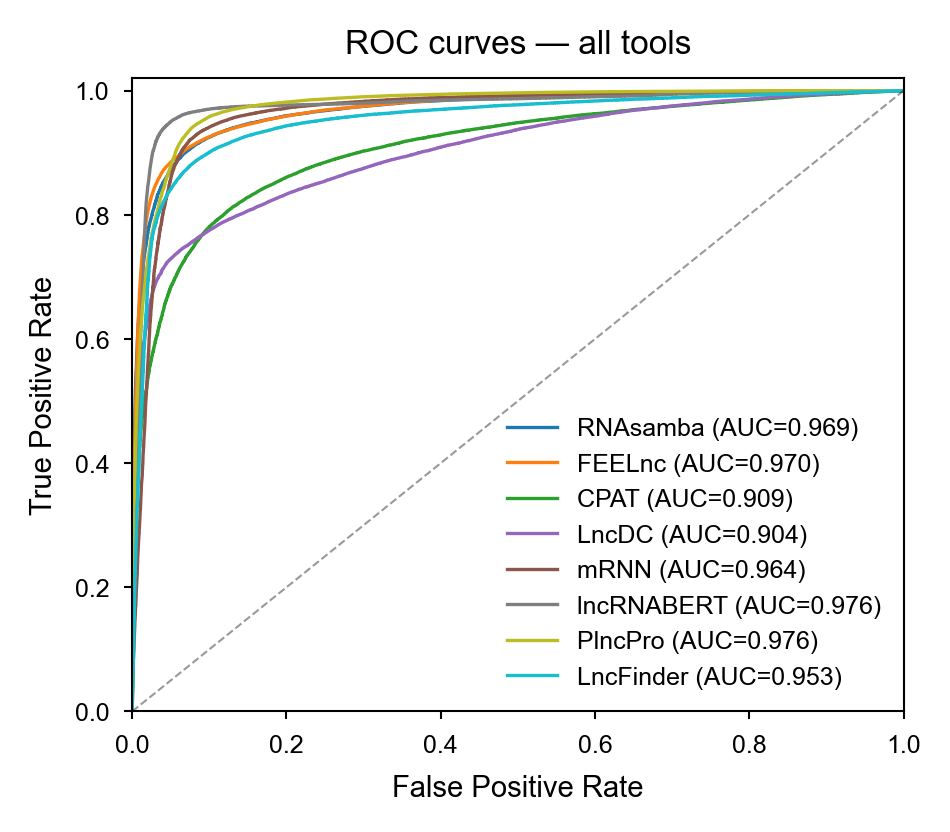

In [ ]:
fig_f1 = plot_roc_curves(
    probs, labels,
    save_path=FIG_DIR / "F1_roc_curves",
)
fig_f1

---
## F2 — Confusion Matrices

  Saved -> F2_confusion_matrices.[pdf/png]


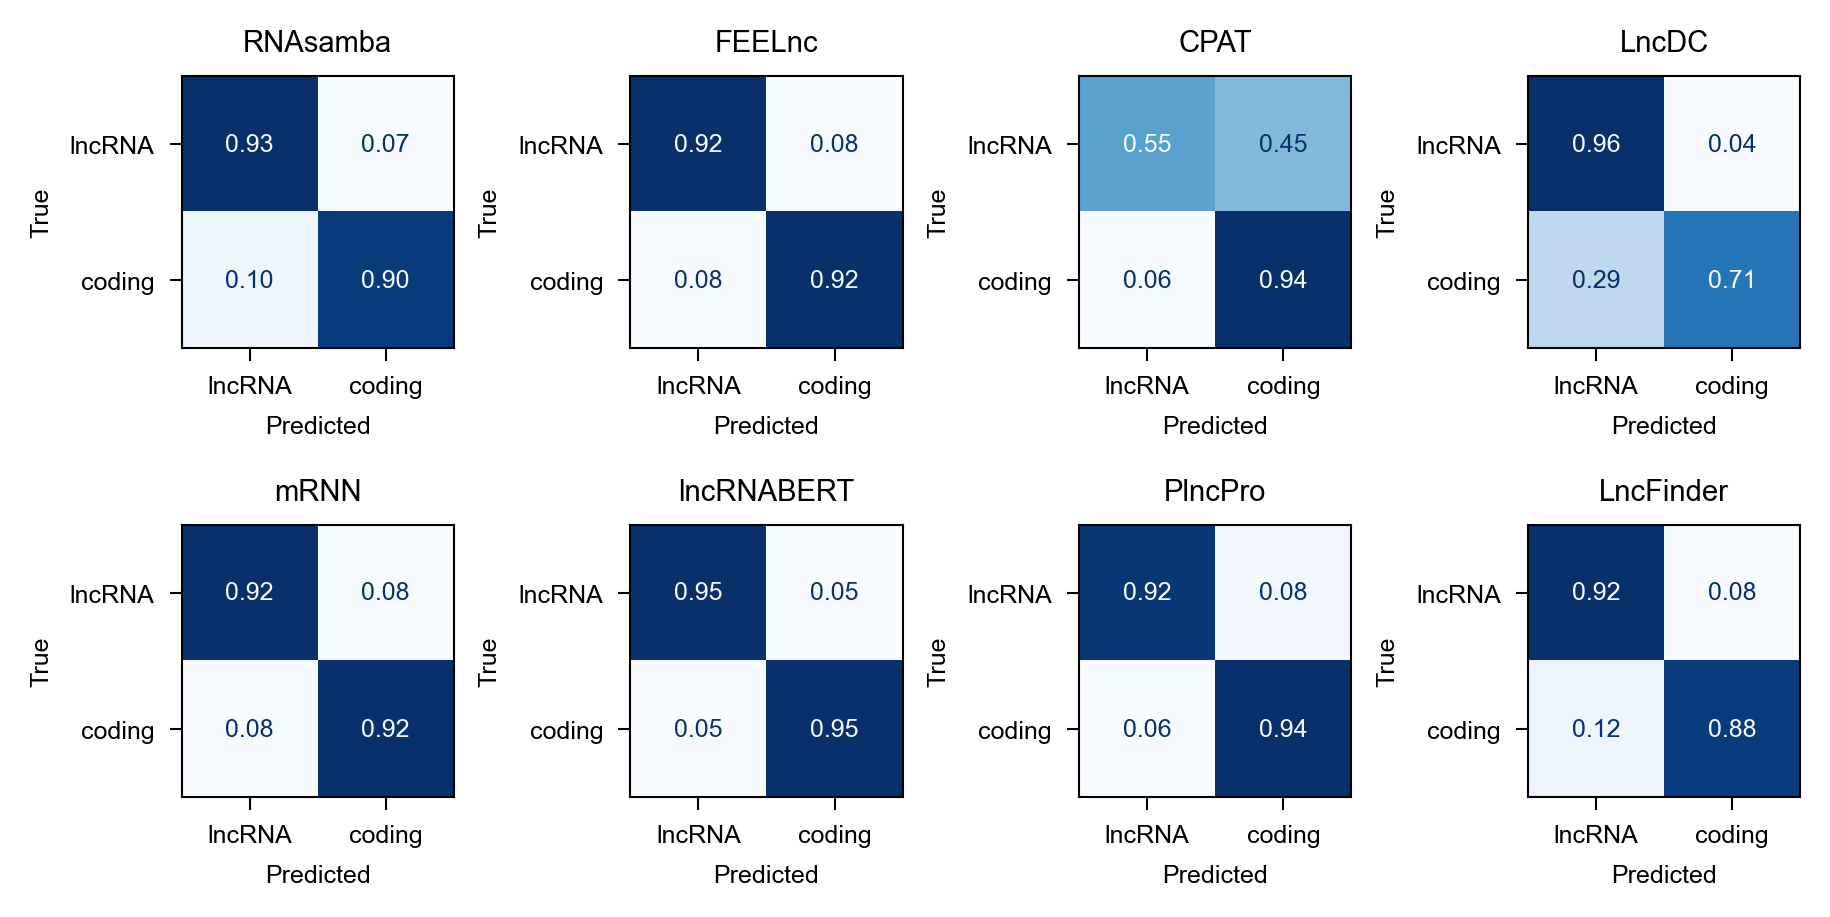

In [ ]:
fig_f2 = plot_confusion_matrices(
    binary_raw,
    n_cols=4,
    save_path=FIG_DIR / "F2_confusion_matrices",
)
fig_f2

---
## F3 — Probability Score Distributions

  Saved -> F3_probability_distributions.[pdf/png]


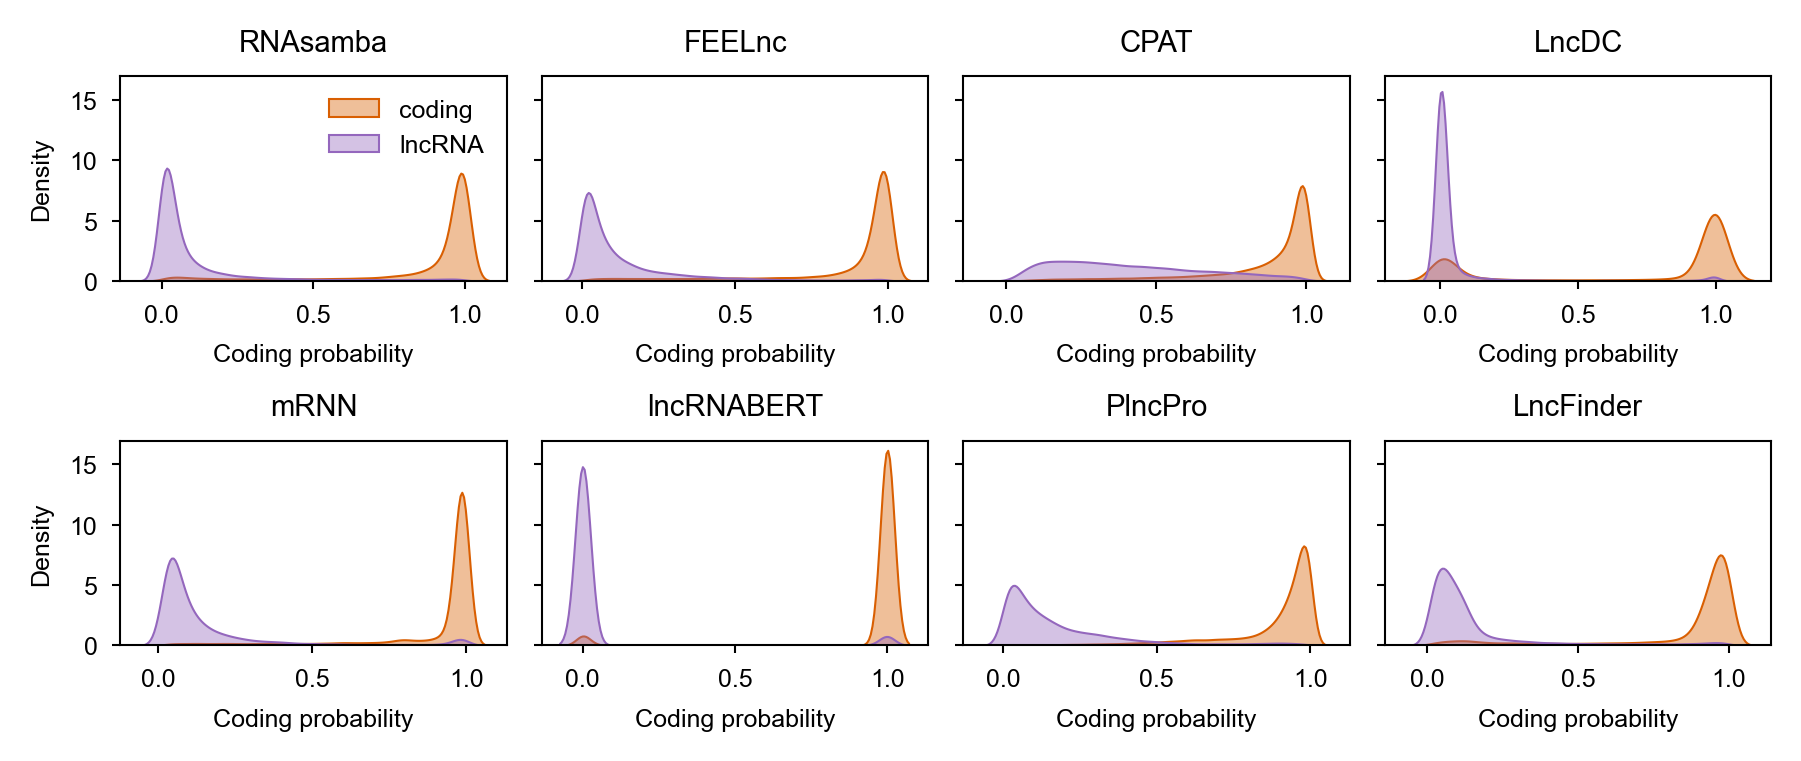

In [ ]:
fig_f3 = plot_probability_distributions(
    probs, labels,
    kde=True,
    n_cols=4,
    save_path=FIG_DIR / "F3_probability_distributions",
)
fig_f3

---
## T5 — Calibration Metrics (ECE / MCE)

In [ ]:
t5 = build_calibration_metrics_table(probs, labels, n_bins=10)
display(t5)
save_table(t5, TABLE_DIR / "T5_calibration_metrics.tsv", index=False)

,tool,ECE,MCE,n_bins_used,underconfident_bins,overconfident_bins,wellcalibrated_bins
0,CPAT,0.2213,0.7758,10,3,7,4
1,LncFinder,0.3339,0.9224,10,9,1,5
2,mRNN,0.3393,0.9560,10,5,5,5
3,PlncPro,0.3414,0.9771,10,10,0,4
4,RNAsamba,0.3514,0.9813,10,9,1,5
5,FEELnc,0.3591,0.9844,10,9,1,4
6,LncDC,0.3821,0.9055,10,6,4,4
7,lncRNABERT,0.3908,0.9777,10,4,6,5


  Saved -> T5_calibration_metrics.tsv  (8 rows x 7 cols)


---
## F4 — Tool Entropy Distributions

  Saved -> F4_tool_entropy_distributions.[pdf/png]


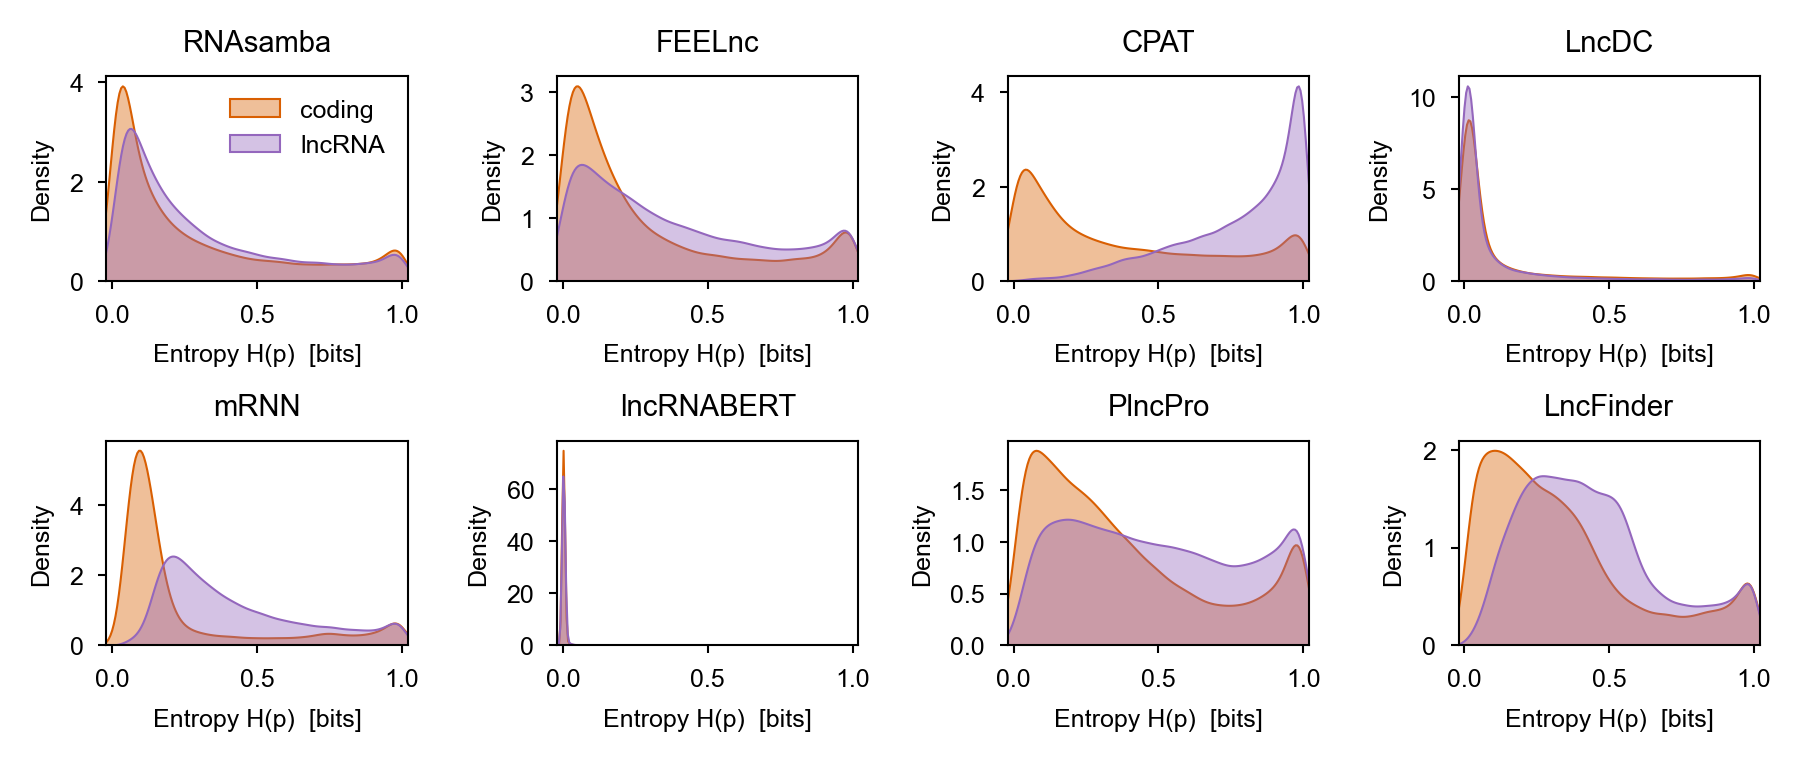

In [ ]:
fig_f4 = plot_tool_entropy_distributions(
    probs, labels,
    n_cols=4,
    save_path=FIG_DIR / "F4_tool_entropy_distributions",
)
fig_f4

---
## F5 — Calibration Curves

  Saved -> F5_calibration_curves.[pdf/png]


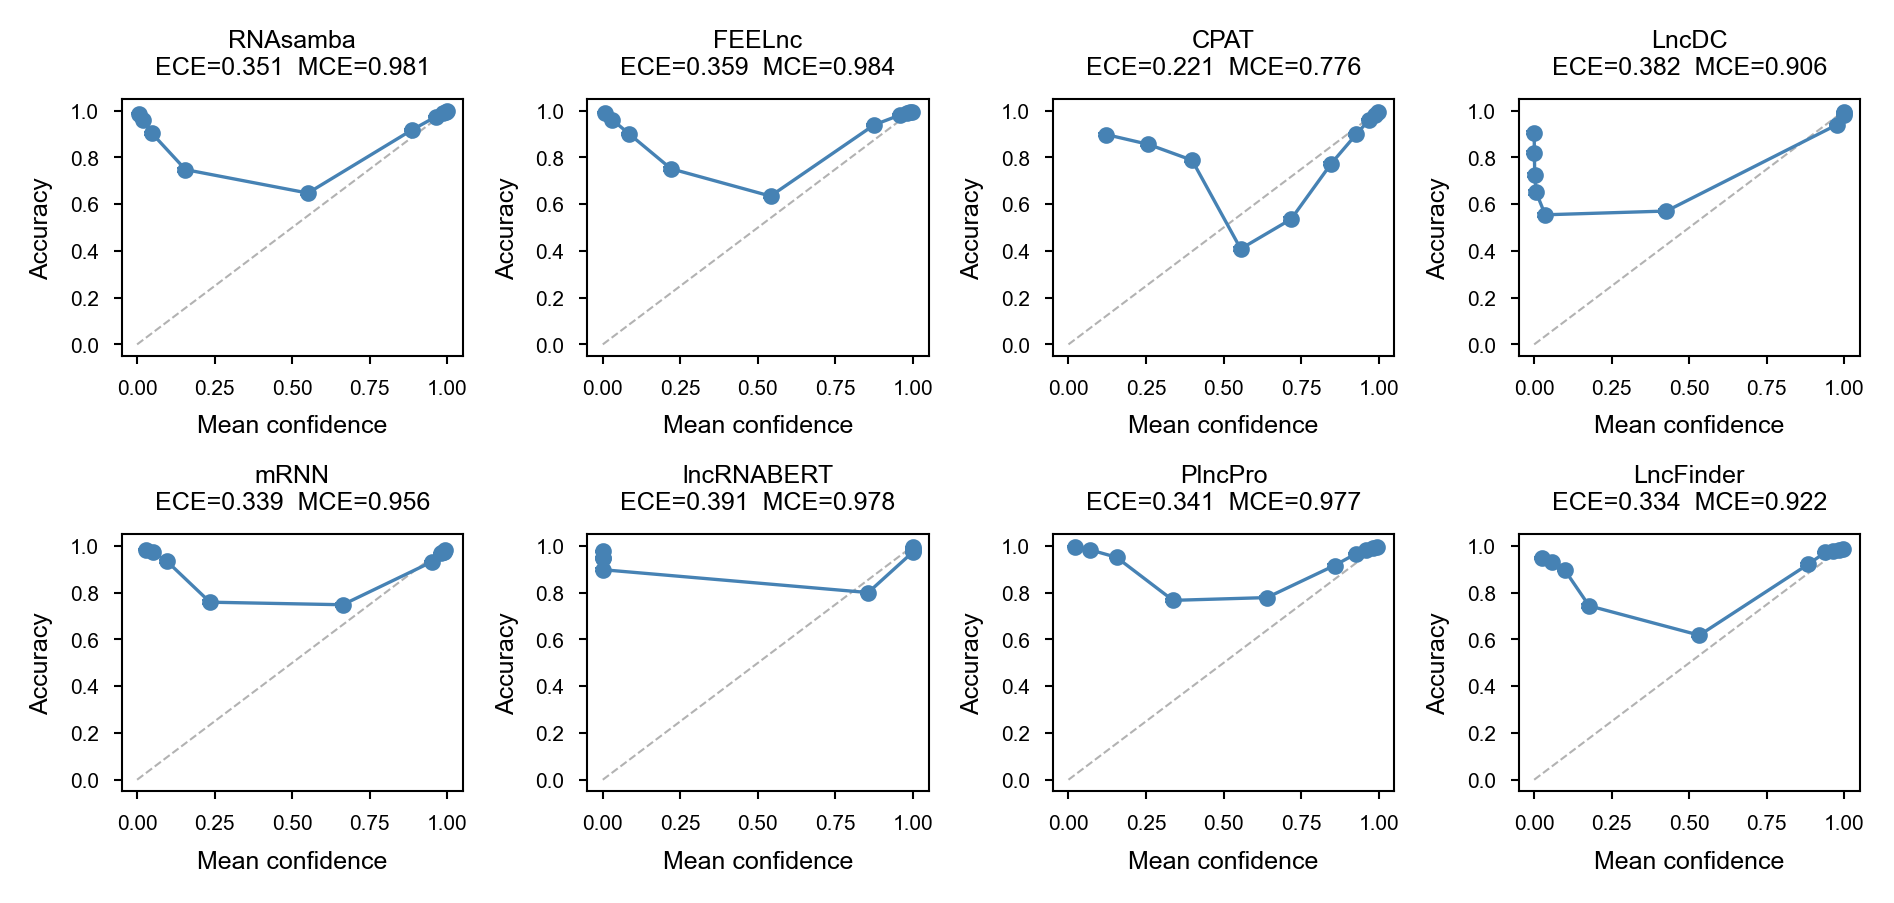

In [ ]:
fig_f5 = plot_calibration_curves(
    probs, labels,
    n_bins=10,
    n_cols=4,
    save_path=FIG_DIR / "F5_calibration_curves",
)
fig_f5

## F5b — Ensemble Reliability (Calibration + Voting Pattern)

ECE (quantile, n_bins=10): 0.0759
ECE (linear,   n_bins=10): 0.0777


,bin,mean_conf,accuracy,n
0,0,0.049626,0.005643,11165
1,1,0.088097,0.016122,11165
2,2,0.132660,0.030631,11165
3,3,0.243859,0.182714,11165
4,4,0.572588,0.797761,11165
5,5,0.811560,0.953426,11165
6,6,0.907569,0.975101,11165
7,7,0.965151,0.987461,11165
8,8,0.982186,0.996686,11165
9,9,0.991334,0.999373,11166


,bin,mean_conf,accuracy,n
0,0,0.065391,0.010194,20307
1,1,0.139360,0.037805,16691
2,2,0.243092,0.166477,5262
3,3,0.346894,0.408088,2992
4,4,0.449590,0.656098,2681
5,5,0.551330,0.824401,2836
6,6,0.653034,0.879778,3610
7,7,0.754711,0.930768,5431
8,8,0.851390,0.966696,11560
9,9,0.970694,0.991460,40282


Saved /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/figures/supplementary/F5b_ensemble_reliability


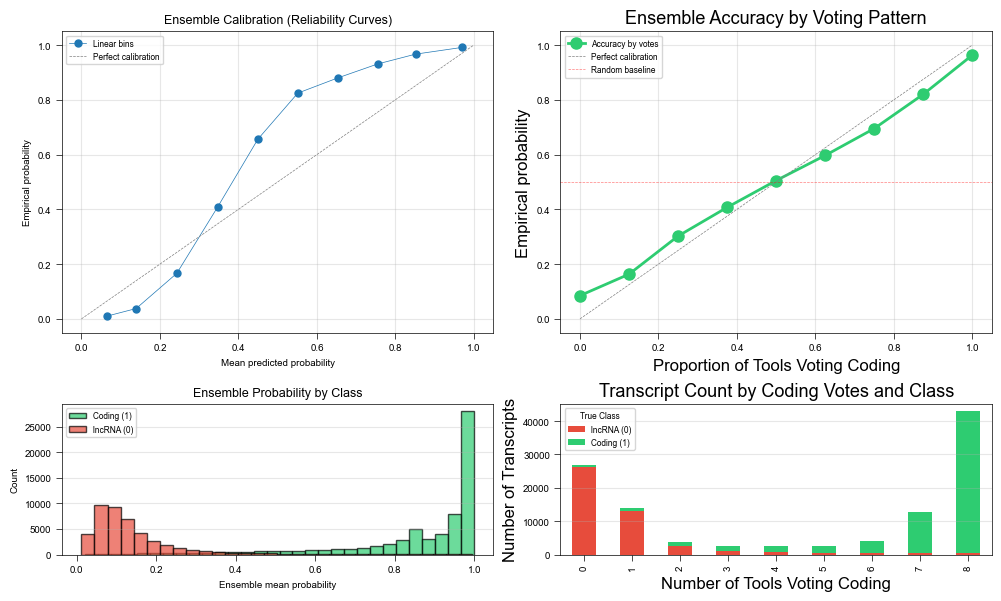

In [ ]:
from sklearn.metrics import balanced_accuracy_score

# ── Derived variables ──────────────────────────────────────────────────────────
y_true         = labels['coding_class'].values
ensemble_prob  = probs.mean(axis=1)
ensemble_pred  = (ensemble_prob > 0.5).astype(int)
n_tools        = probs.shape[1]
# binary vote per tool: prob > 0.5 → coding vote
binary_votes   = (probs.values > 0.5).astype(int)
n_coding_votes = binary_votes.sum(axis=1)

# ── Calibration helper ─────────────────────────────────────────────────────────
def compute_calibration(prob, y, bin_edges):
    if bin_edges.size < 2:
        raise ValueError("Not enough unique values for binning.")
    bin_edges = bin_edges.copy()
    bin_edges[-1] = bin_edges[-1] + 1e-12
    bin_idx = np.digitize(prob, bin_edges, right=True) - 1
    rows = []
    for i in range(len(bin_edges) - 1):
        mask = bin_idx == i
        if mask.sum() == 0:
            continue
        rows.append({
            "bin": i,
            "mean_conf": prob[mask].mean(),
            "accuracy": y[mask].mean(),
            "n": mask.sum()
        })
    calib_df = pd.DataFrame(rows)
    ece = np.sum(np.abs(calib_df["accuracy"] - calib_df["mean_conf"]) * (calib_df["n"] / len(prob)))
    return calib_df, ece

n_bins = 10
quantile_edges = np.unique(np.percentile(ensemble_prob, np.linspace(0, 100, n_bins + 1)))
calib_quantile_df, ece_quantile = compute_calibration(ensemble_prob.values, y_true, quantile_edges)
linear_edges = np.linspace(0, 1, n_bins + 1)
calib_linear_df,   ece_linear   = compute_calibration(ensemble_prob.values, y_true, linear_edges)

print(f"ECE (quantile, n_bins={n_bins}): {ece_quantile:.4f}")
print(f"ECE (linear,   n_bins={n_bins}): {ece_linear:.4f}")
display(calib_quantile_df)
display(calib_linear_df)

# ── Accuracy by votes ──────────────────────────────────────────────────────────
accuracy_by_votes = []
for n_votes in range(n_tools + 1):
    mask = (n_coding_votes == n_votes)
    if mask.sum() > 0:
        accuracy_by_votes.append({
            'n_coding_votes': n_votes,
            'proportion_coding_votes': n_votes / n_tools,
            'n': mask.sum(),
            'accuracy': ensemble_prob.values[mask].mean()
        })
accuracy_by_votes_df = pd.DataFrame(accuracy_by_votes)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig_f5b, axes = plt.subplots(2, 2, figsize=(10, 6), gridspec_kw={"height_ratios": [2, 1]})

ax = axes[0, 0]
ax.plot(calib_linear_df["mean_conf"], calib_linear_df["accuracy"], marker="o", label="Linear bins")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Empirical probability")
ax.set_title("Ensemble Calibration (Reliability Curves)")
ax.grid(alpha=0.3)
ax.legend()

ax = axes[0, 1]
ax.plot(accuracy_by_votes_df['proportion_coding_votes'], accuracy_by_votes_df['accuracy'],
        marker='o', linewidth=2, markersize=8, color='#2ecc71', label='Accuracy by votes')
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.set_xlabel('Proportion of Tools Voting Coding', fontsize=12)
ax.set_ylabel('Empirical probability', fontsize=12)
ax.set_title('Ensemble Accuracy by Voting Pattern', fontsize=13)
ax.grid(True, alpha=0.3)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
ax.legend()

axes[1, 0].hist(ensemble_prob.values[y_true == 1], bins=30, alpha=0.7, label="Coding (1)",  color="#2ecc71", edgecolor="black")
axes[1, 0].hist(ensemble_prob.values[y_true == 0], bins=30, alpha=0.7, label="lncRNA (0)", color="#e74c3c", edgecolor="black")
axes[1, 0].set_xlabel("Ensemble mean probability")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Ensemble Probability by Class")
axes[1, 0].grid(alpha=0.3, axis="y")
axes[1, 0].legend()

vote_class_counts = pd.DataFrame({
    'n_coding_votes': n_coding_votes,
    'true_label': y_true
}).groupby(['n_coding_votes', 'true_label']).size().unstack(fill_value=0)
vote_class_counts.plot(kind='bar', stacked=True, ax=axes[1, 1], color=['#e74c3c', '#2ecc71'])
axes[1, 1].set_xlabel('Number of Tools Voting Coding', fontsize=12)
axes[1, 1].set_ylabel('Number of Transcripts', fontsize=12)
axes[1, 1].set_title('Transcript Count by Coding Votes and Class', fontsize=13)
axes[1, 1].legend(title='True Class', labels=['lncRNA (0)', 'Coding (1)'])
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = FIG_DIR / "F5b_ensemble_reliability"
fig_f5b.savefig(save_path.with_suffix(".pdf"), bbox_inches="tight")
fig_f5b.savefig(save_path.with_suffix(".png"), dpi=300, bbox_inches="tight")
print(f"Saved {save_path}")
fig_f5b

In [ ]:
# Entropy data for F6/F7/F8 — load from pre-computed TSV when available,
# then attach ensemble_pred (not stored in TSV) and biotype from labels.
if entropy_available:
    entropy_plot_df = pd.read_csv(ENTROPY_TSV, sep='\t', index_col=0)
    entropy_plot_df = entropy_plot_df.reindex(probs.index)
    # ensemble_pred is not in the TSV — derive from mean probability
    entropy_plot_df['ensemble_pred']  = (probs.mean(axis=1) > 0.5).astype(int)
    entropy_plot_df['coding_class']   = labels['coding_class']
    entropy_plot_df['biotype']        = labels['biotype']
    print(f'entropy_plot_df: {entropy_plot_df.shape}, columns: {list(entropy_plot_df.columns)}')
    THRESHOLDS = list(range(5, 46, 5))
    overall_acc = __import__('sklearn.metrics', fromlist=['balanced_accuracy_score']).balanced_accuracy_score(
        entropy_plot_df['coding_class'], entropy_plot_df['ensemble_pred']
    )
    print(f'Overall balanced accuracy: {overall_acc:.4f}')
else:
    print('Entropy TSV not found — F6/F7/F8 will be skipped')

entropy_plot_df: (111652, 14), columns: ['coding_score_rnasamba_entropy', 'coding_potential_feelnc_entropy', 'Coding_prob_l_cpat_entropy', 'Noncoding_prob_ss_lncDC_entropy', 'coding_prob_mrnn_entropy', 'P(pcRNA)_lncrnabert_entropy', 'prob_coding_plncpro_entropy', 'Coding.Potential_ss_lncfinder_entropy', 'H_exp', 'H_pred', 'I_bald', 'coding_class', 'biotype', 'ensemble_pred']
Overall balanced accuracy: 0.9421


---
## F6 — Entropy Distribution by Class

In [ ]:
if entropy_available:
    fig_f6 = plot_entropy_by_class(
        entropy_plot_df,
        entropy_col='H_pred',
        save_path=FIG_DIR / 'F6_entropy_by_class',
    )
    fig_f6
    plt.show()

  Saved -> F6_entropy_by_class.[pdf/png]


---
## F7 — Accuracy vs Threshold (Strategy 1: overall)

Pre-computed results are saved to TSV and reloaded if already present.

In [ ]:
if entropy_available:
    s1_tsv = TABLE_DIR / 'F7_accuracy_vs_threshold_s1.tsv'
    if s1_tsv.exists():
        s1_acc_df = pd.read_csv(s1_tsv, sep='\t')
        print(f'Loaded from {s1_tsv.name}')
    else:
        s1_acc_df = compute_accuracy_vs_threshold(
            entropy_plot_df, THRESHOLDS, by_class=False
        )
        save_table(s1_acc_df, s1_tsv, index=False)

    fig_f7 = plot_accuracy_vs_threshold(
        s1_acc_df, overall_acc=overall_acc,
        title='Strategy 1 — overall thresholds',
        save_path=FIG_DIR / 'F7_accuracy_vs_threshold_s1',
    )
    fig_f7

DEBUG:matplotlib.backends.backend_pdf:Assigning font /F1 = '/home/dgarcia/.local/share/fonts/Arial.TTF'
DEBUG:matplotlib.backends.backend_pdf:Embedding font /home/dgarcia/.local/share/fonts/Arial.TTF.
DEBUG:matplotlib.backends.backend_pdf:Writing TrueType font.
DEBUG:matplotlib.backends.backend_pdf:SUBSET /home/dgarcia/.local/share/fonts/Arial.TTF characters: — ().0123456789BLOSacdeghilmnoprstuvwy
DEBUG:fontTools.subset.timer:Took 0.001s to load font
DEBUG:fontTools.ttLib.ttFont:Reading 'maxp' table from disk
DEBUG:fontTools.ttLib.ttFont:Decompiling 'maxp' table
DEBUG:fontTools.subset.timer:Took 0.001s to load 'maxp'
DEBUG:fontTools.subset.timer:Took 0.000s to prune 'maxp'
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
DEBUG:fontTools.ttLib.ttFont:Reading 'cmap' table from disk
DEBUG:fontTools.ttLib.ttFont:Decompiling 'cmap' table
DEBUG:fontTools.subset.timer:Took 0.001s to load 'cmap'
DEBUG:fontTools.subset.timer:Took 0.000s to prune 'cmap'
INFO:fontTools.subset:

  Saved -> F7_accuracy_vs_threshold_s1.tsv  (27 rows x 4 cols)
  Saved -> F7_accuracy_vs_threshold_s1.[pdf/png]


---
## F8 — Accuracy vs Threshold (Strategy 2: per class)

Pre-computed results are saved to TSV and reloaded if already present.

In [ ]:
if entropy_available:
    s2_tsv = TABLE_DIR / 'F8_accuracy_vs_threshold_s2.tsv'
    if s2_tsv.exists():
        s2_acc_df = pd.read_csv(s2_tsv, sep='\t')
        print(f'Loaded from {s2_tsv.name}')
    else:
        s2_acc_df = compute_accuracy_vs_threshold(
            entropy_plot_df, THRESHOLDS, by_class=True
        )
        save_table(s2_acc_df, s2_tsv, index=False)

    fig_f8 = plot_accuracy_vs_threshold(
        s2_acc_df, overall_acc=overall_acc,
        title='Strategy 2 — class-separated thresholds',
        save_path=FIG_DIR / 'F8_accuracy_vs_threshold_s2',
    )
    fig_f8

DEBUG:matplotlib.backends.backend_pdf:Assigning font /F1 = '/home/dgarcia/.local/share/fonts/Arial.TTF'
DEBUG:matplotlib.backends.backend_pdf:Embedding font /home/dgarcia/.local/share/fonts/Arial.TTF.
DEBUG:matplotlib.backends.backend_pdf:Writing TrueType font.
DEBUG:matplotlib.backends.backend_pdf:SUBSET /home/dgarcia/.local/share/fonts/Arial.TTF characters: — ()-.0123456789BLOSacdeghilmnoprstuvwy
DEBUG:fontTools.subset.timer:Took 0.001s to load font
DEBUG:fontTools.ttLib.ttFont:Reading 'maxp' table from disk
DEBUG:fontTools.ttLib.ttFont:Decompiling 'maxp' table
DEBUG:fontTools.subset.timer:Took 0.001s to load 'maxp'
DEBUG:fontTools.subset.timer:Took 0.000s to prune 'maxp'
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
DEBUG:fontTools.ttLib.ttFont:Reading 'cmap' table from disk
DEBUG:fontTools.ttLib.ttFont:Decompiling 'cmap' table
DEBUG:fontTools.subset.timer:Took 0.001s to load 'cmap'
DEBUG:fontTools.subset.timer:Took 0.000s to prune 'cmap'
INFO:fontTools.subset

  Saved -> F8_accuracy_vs_threshold_s2.tsv  (27 rows x 4 cols)
  Saved -> F8_accuracy_vs_threshold_s2.[pdf/png]


---
## F9 — Feature Correlation Heatmap

Selected 128 numeric features (out of 128 total) for correlation analysis


DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x7fc547998c80>
DEBUG:matplotlib.backends.backend_pdf:Assigning font /F1 = '/home/dgarcia/.local/share/fonts/Arial.TTF'
DEBUG:matplotlib.backends.backend_pdf:Embedding font /home/dgarcia/.local/share/fonts/Arial.TTF.
DEBUG:matplotlib.backends.backend_pdf:Writing TrueType font.
DEBUG:matplotlib.backends.backend_pdf:SUBSET /home/dgarcia/.local/share/fonts/Arial.TTF characters: − (),.012578=FSaceilmnoprstux
DEBUG:fontTools.subset.timer:Took 0.001s to load font
DEBUG:fontTools.ttLib.ttFont:Reading 'maxp' table from disk
DEBUG:fontTools.ttLib.ttFont:Decompiling 'maxp' table
DEBUG:fontTools.subset.timer:Took 0.001s to load 'maxp'
DEBUG:fontTools.subset.timer:Took 0.000s to prune 'maxp'
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
DEBUG:fontTools.ttLib.ttFont:Reading 'cmap' table from disk
DEBUG:fontTools.ttLib.ttFont:Decompiling 'cmap' table
DEBUG:fontTools.subset.timer:Took 0.001s to load 'cm

  Saved -> F9_feature_correlation_heatmap.[pdf/png]


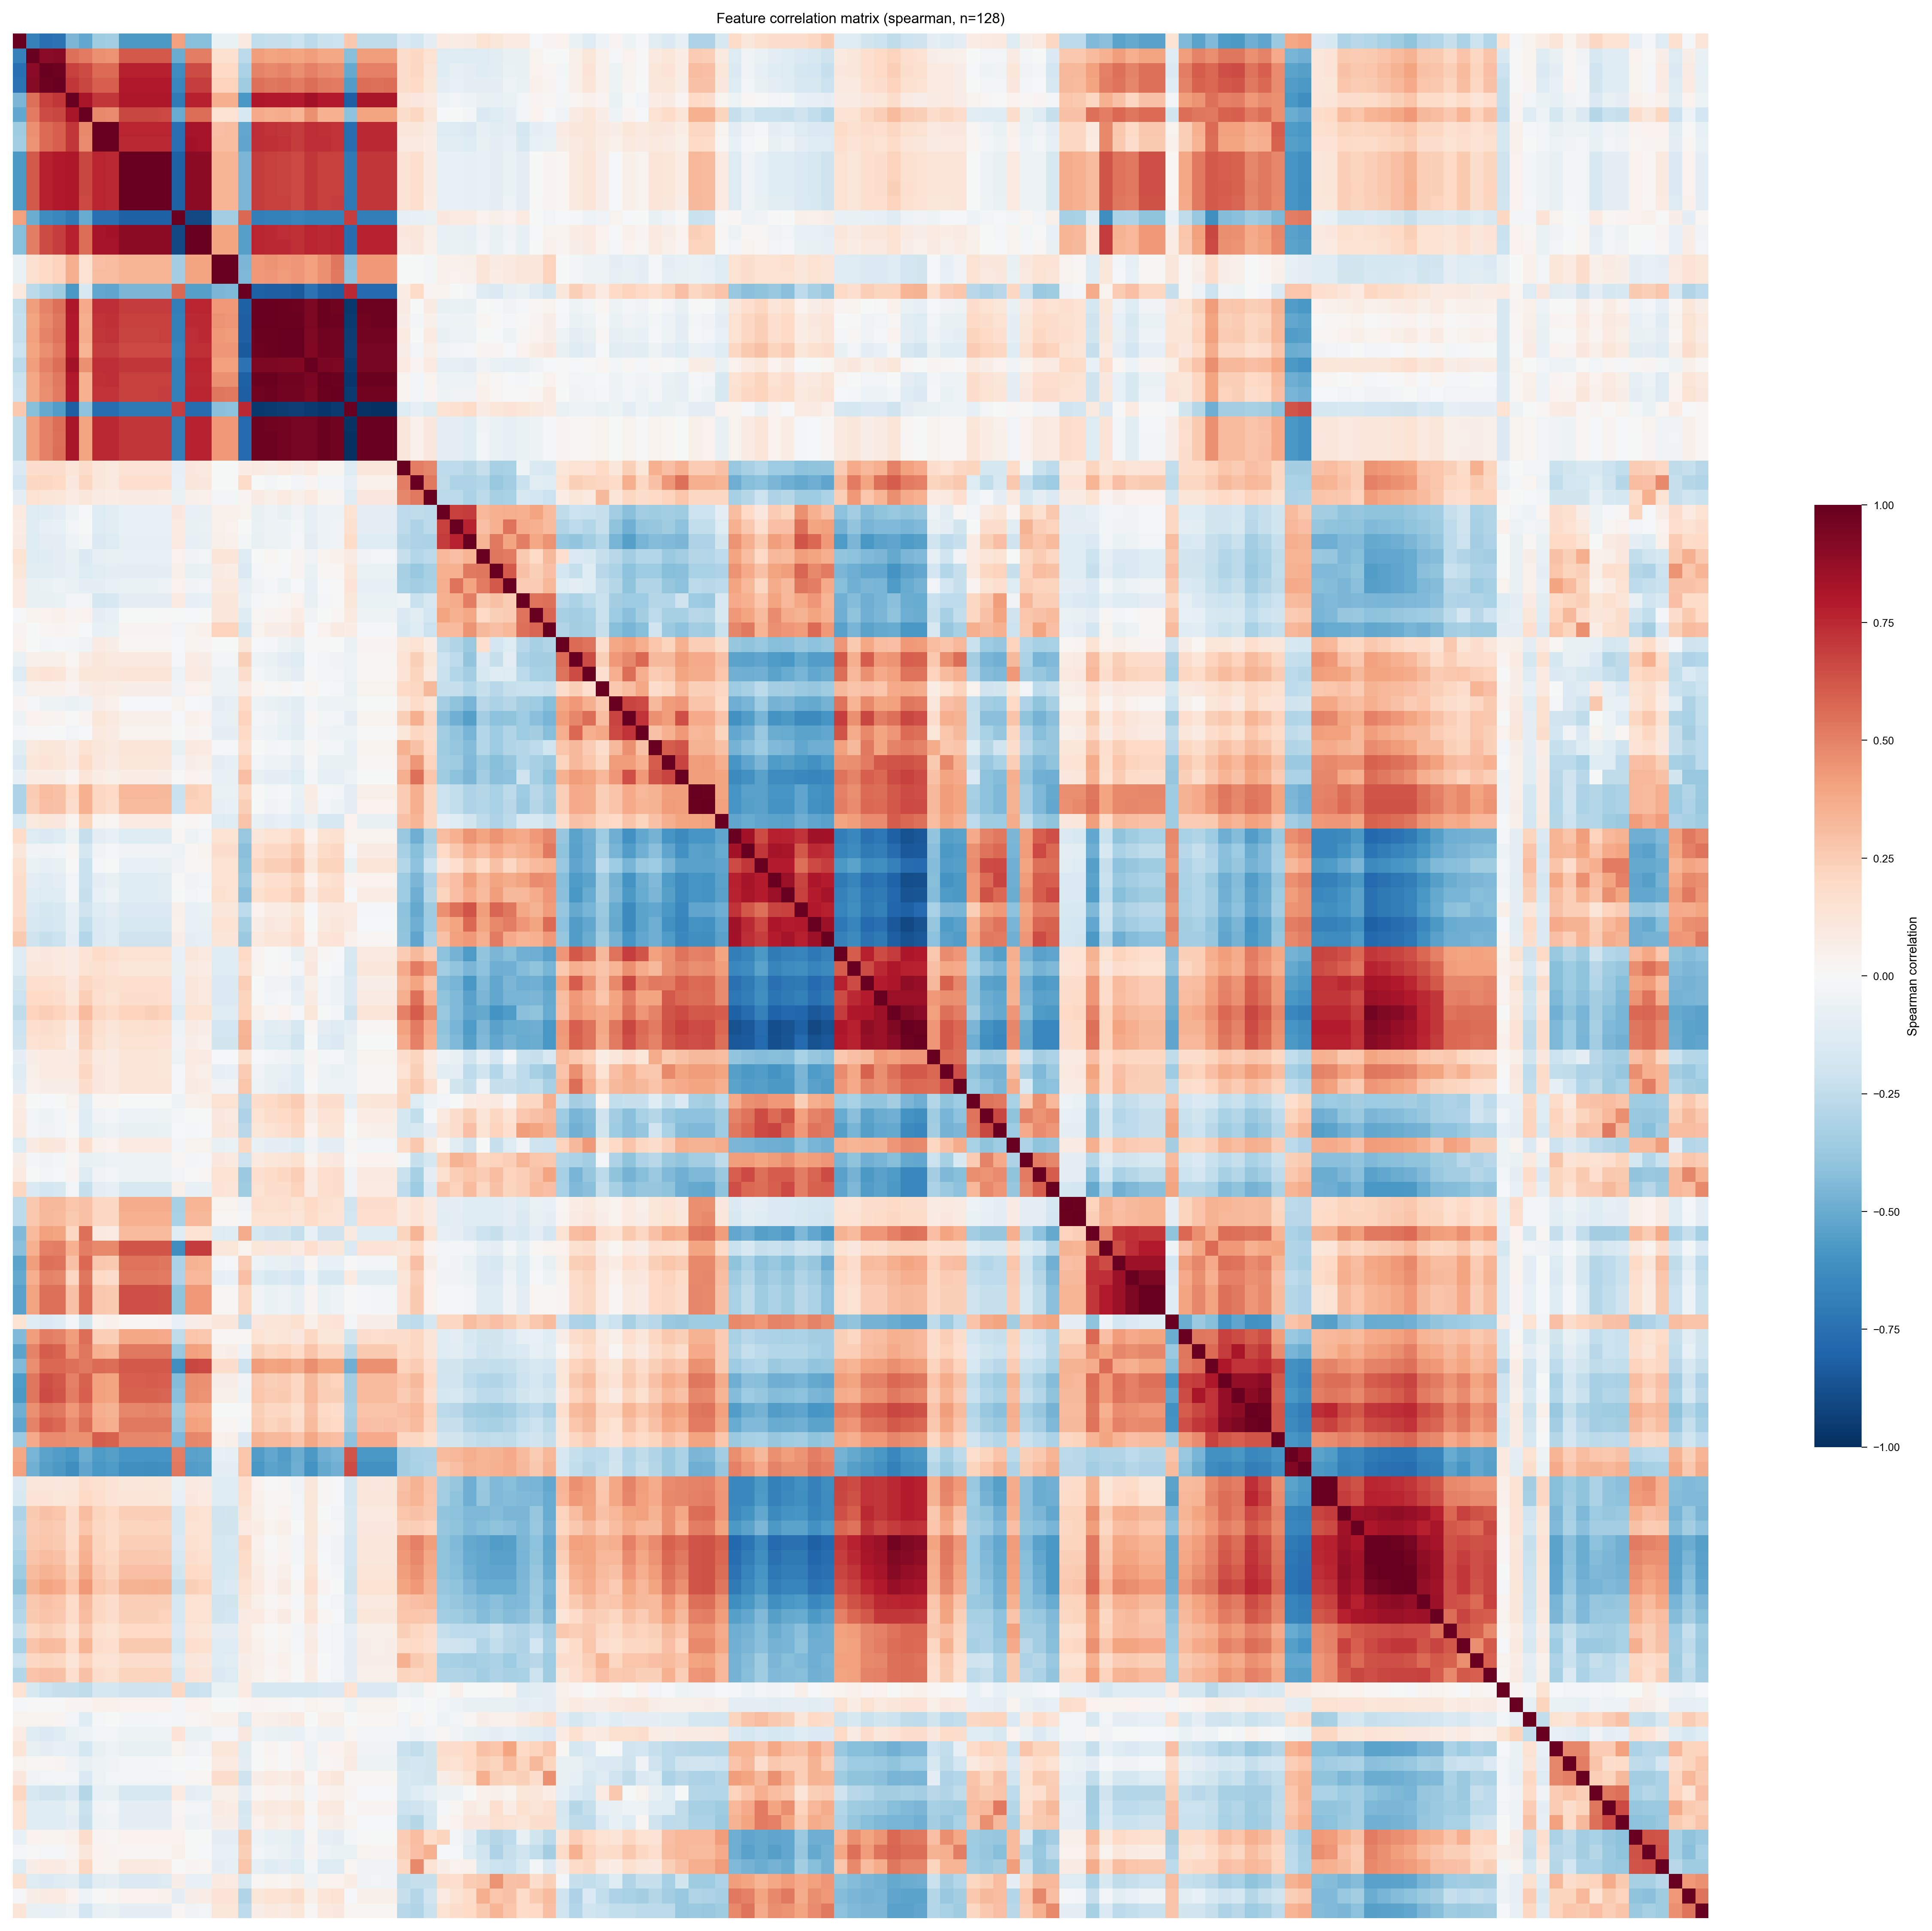

In [ ]:
fig_f9 = plot_feature_correlation_heatmap(
    scalar,
    method="spearman",
    save_path=FIG_DIR / "F9_feature_correlation_heatmap",
)
fig_f9

---
## F10 — Feature Dendrogram

Selected 128 numeric features (out of 128 total) for correlation analysis


DEBUG:matplotlib.backends.backend_pdf:Assigning font /F1 = '/home/dgarcia/.local/share/fonts/Arial.TTF'
DEBUG:matplotlib.backends.backend_pdf:Embedding font /home/dgarcia/.local/share/fonts/Arial.TTF.
DEBUG:matplotlib.backends.backend_pdf:Writing TrueType font.
DEBUG:matplotlib.backends.backend_pdf:SUBSET /home/dgarcia/.local/share/fonts/Arial.TTF characters:  (),-./012345689=ABCDFGHILMNOPQRSTUW_abcdefghiklmnopqrstuvxy
DEBUG:fontTools.subset.timer:Took 0.001s to load font
DEBUG:fontTools.ttLib.ttFont:Reading 'maxp' table from disk
DEBUG:fontTools.ttLib.ttFont:Decompiling 'maxp' table
DEBUG:fontTools.subset.timer:Took 0.001s to load 'maxp'
DEBUG:fontTools.subset.timer:Took 0.000s to prune 'maxp'
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
DEBUG:fontTools.ttLib.ttFont:Reading 'cmap' table from disk
DEBUG:fontTools.ttLib.ttFont:Decompiling 'cmap' table
DEBUG:fontTools.subset.timer:Took 0.001s to load 'cmap'
DEBUG:fontTools.subset.timer:Took 0.000s to prune 'cmap'


  Saved -> F10_feature_dendrogram.[pdf/png]


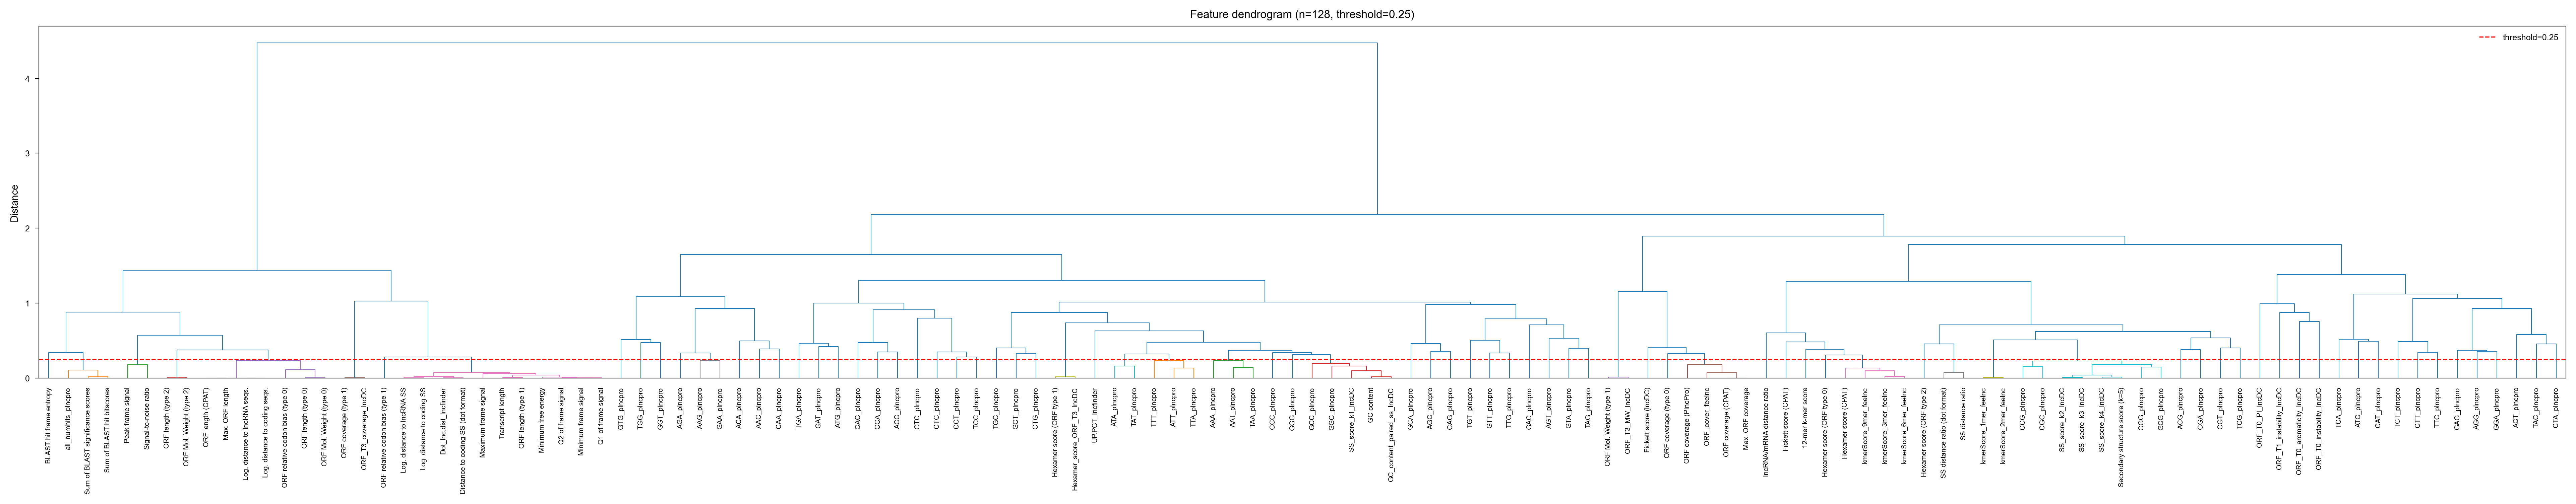

In [ ]:
fig_f10 = plot_feature_dendrogram(
    scalar,
    distance_threshold=0.25,
    save_path=FIG_DIR / "F10_feature_dendrogram",
)
fig_f10

---
## T6 — Inter-tool Agreement (Cohen's κ and Spearman ρ)

In [ ]:
binary_cols = [col for col in binary_raw.columns if col not in ["fold", "real"]]
binary_raw[binary_cols]

,rnasamba,feelnc,p_cpat,l_cpat,lncDC,ss_lncDC,mrnn,lncrnabert,plncpro,ss_lncfinder,lncfinder
seq_ID,,,,,,,,,,,
ENST00000000412.8,True,True,True,True,True,True,True,True,True,True,True
ENST00000002596.6,True,True,True,True,True,True,True,True,True,True,True
ENST00000002829.8,True,True,True,True,True,True,True,True,True,True,True
ENST00000005260.9,True,True,True,True,True,True,True,True,True,True,True
ENST00000005995.8,True,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...
ENST00000715715.1,False,False,True,False,False,False,False,False,False,False,False
ENST00000715718.1,False,False,True,False,False,False,False,False,False,False,False
ENST00000715720.1,False,False,True,False,False,False,False,False,False,False,False


In [ ]:
from sklearn.metrics import cohen_kappa_score
from scipy.stats import spearmanr
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

In [ ]:
tools = probs.columns.tolist()

prob_prefixes = [p[:8] for p in tools]
possible_prob_cols = [col for col in features_df.columns if any(col.startswith(prefix) for prefix in prob_prefixes)]
all_probs = features_df[possible_prob_cols]

In [ ]:
possible_prob_cols

['coding_score_rnasamba',
 'coding_potential_feelnc',
 'Coding_prob_p_cpat',
 'Coding_prob_l_cpat',
 'Noncoding_prob_lncDC',
 'Noncoding_prob_ss_lncDC',
 'coding_prob_mrnn',
 'P(pcRNA)_lncrnabert',
 'prob_coding_plncpro',
 'Coding.Potential_ss_lncfinder',
 'Coding.Potential_lncfinder']

In [ ]:
def generate_kappa_matrix(labels, tools):
    kappa_mat = pd.DataFrame(np.ones((len(tools), len(tools))), index=tools, columns=tools)
    for i, ta in enumerate(tools):
        for j, tb in enumerate(tools):
            if i < j:
                k = cohen_kappa_score(labels[ta], labels[tb])
                kappa_mat.loc[ta, tb] = k
                kappa_mat.loc[tb, ta] = k
    return kappa_mat

def generate_spearman_matrix(all_probs, tools):
    spearman_mat = pd.DataFrame(np.ones((len(tools), len(tools))), index=tools, columns=tools)
    for i, ta in enumerate(tools):
        for j, tb in enumerate(tools):
            if i < j:
                rho, _ = spearmanr(all_probs[ta], all_probs[tb])
                spearman_mat.loc[ta, tb] = rho
                spearman_mat.loc[tb, ta] = rho
    return spearman_mat

In [ ]:
sum(binary_raw["l_cpat"] == binary_raw["p_cpat"])

88330

In [ ]:
sum(binary_raw["l_cpat"] == binary_raw["feelnc"])

87314

In [ ]:
coding_scores_cols = ['coding_score_rnasamba',
 'coding_potential_feelnc',
 'Coding_prob_p_cpat',
 'Coding_prob_l_cpat',
 'Noncoding_prob_ss_lncDC',
 'Noncoding_prob_lncDC',
 'coding_prob_mrnn',
 'P(pcRNA)_lncrnabert',
 'prob_coding_plncpro',
 'Coding.Potential_ss_lncfinder',
 'Coding.Potential_lncfinder']

tool_names = [
    'rnasamba',
 'feelnc',
 'p_cpat',
 'l_cpat',
 'ss_lncDC',
 'lncDC',
 'mrnn',
 'lncrnabert',
 'plncpro',
 'ss_lncfinder',
 'lncfinder']

invert_cols = [col for col in coding_scores_cols if col.startswith(('Noncoding_prob'))]
all_probs[invert_cols] = 1 - all_probs[invert_cols]

all_probs.columns = tool_names




Cohen's κ — pairwise hard-label agreement:


,rnasamba,feelnc,p_cpat,l_cpat,lncDC,ss_lncDC,mrnn,lncrnabert,plncpro,ss_lncfinder,lncfinder
rnasamba,1.000,0.829,0.109,0.526,0.675,0.686,0.849,0.842,0.838,0.863,0.846
feelnc,0.829,1.000,0.110,0.529,0.652,0.659,0.823,0.830,0.819,0.841,0.832
p_cpat,0.109,0.110,1.000,0.255,0.070,0.072,0.120,0.116,0.119,0.110,0.107
l_cpat,0.526,0.529,0.255,1.000,0.386,0.391,0.541,0.523,0.532,0.540,0.532
lncDC,0.675,0.652,0.070,0.386,1.000,0.956,0.660,0.637,0.632,0.698,0.702
ss_lncDC,0.686,0.659,0.072,0.391,0.956,1.000,0.673,0.649,0.645,0.702,0.703
mrnn,0.849,0.823,0.120,0.541,0.660,0.673,1.000,0.869,0.868,0.834,0.818
lncrnabert,0.842,0.830,0.116,0.523,0.637,0.649,0.869,1.000,0.863,0.812,0.796
plncpro,0.838,0.819,0.119,0.532,0.632,0.645,0.868,0.863,1.000,0.820,0.807
ss_lncfinder,0.863,0.841,0.110,0.540,0.698,0.702,0.834,0.812,0.820,1.000,0.941



Spearman ρ — pairwise probability correlation:


,rnasamba,feelnc,p_cpat,l_cpat,lncDC,ss_lncDC,mrnn,lncrnabert,plncpro,ss_lncfinder,lncfinder
rnasamba,1.000,0.879,0.754,0.809,0.800,0.766,0.830,0.771,0.880,0.842,0.829
feelnc,0.879,1.000,0.745,0.807,0.761,0.729,0.832,0.751,0.860,0.827,0.816
p_cpat,0.754,0.745,1.000,0.877,0.688,0.674,0.736,0.630,0.746,0.704,0.721
l_cpat,0.809,0.807,0.877,1.000,0.733,0.720,0.766,0.671,0.782,0.784,0.792
lncDC,0.800,0.761,0.688,0.733,1.000,0.961,0.699,0.658,0.778,0.724,0.719
ss_lncDC,0.766,0.729,0.674,0.720,0.961,1.000,0.658,0.618,0.743,0.693,0.693
mrnn,0.830,0.832,0.736,0.766,0.699,0.658,1.000,0.749,0.846,0.803,0.776
lncrnabert,0.771,0.751,0.630,0.671,0.658,0.618,0.749,1.000,0.766,0.735,0.719
plncpro,0.880,0.860,0.746,0.782,0.778,0.743,0.846,0.766,1.000,0.788,0.781
ss_lncfinder,0.842,0.827,0.704,0.784,0.724,0.693,0.803,0.735,0.788,1.000,0.906


  Saved -> T6a_cohen_kappa.tsv  (11 rows x 11 cols)
  Saved -> T6b_spearman_rho.tsv  (11 rows x 11 cols)


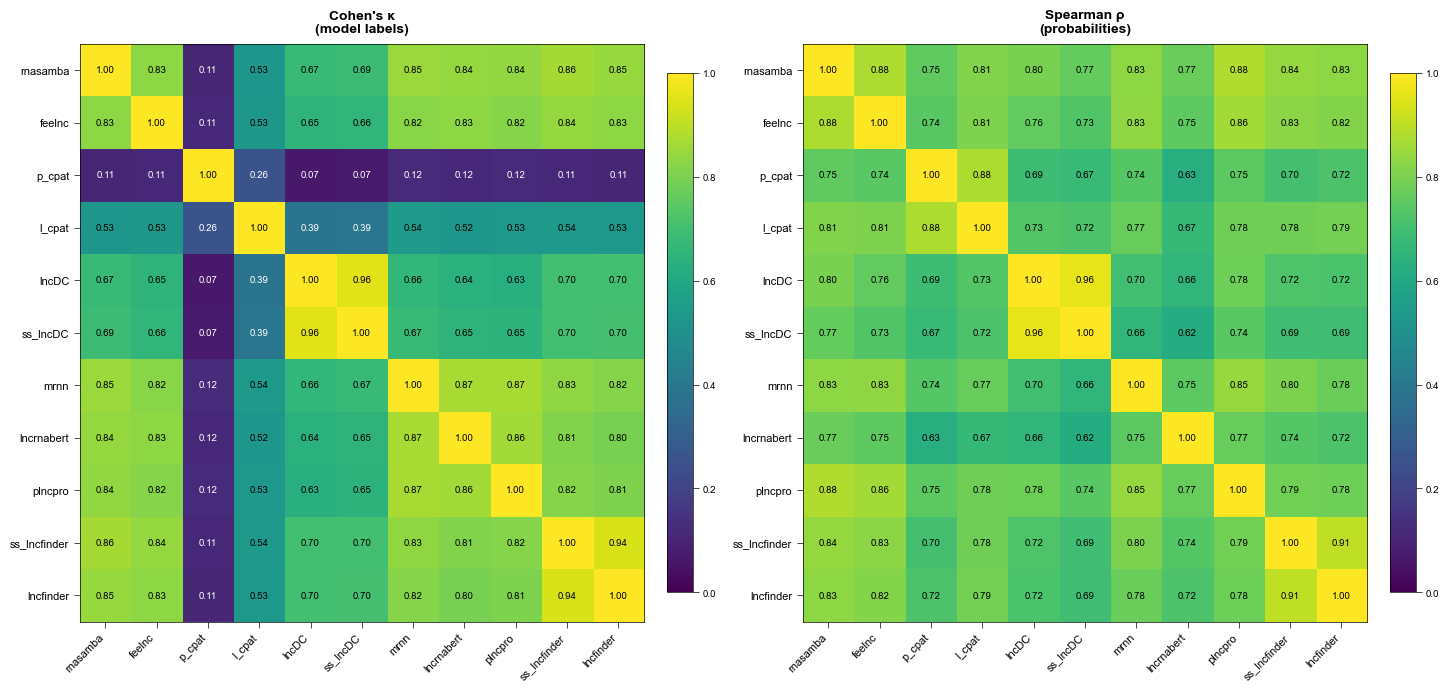

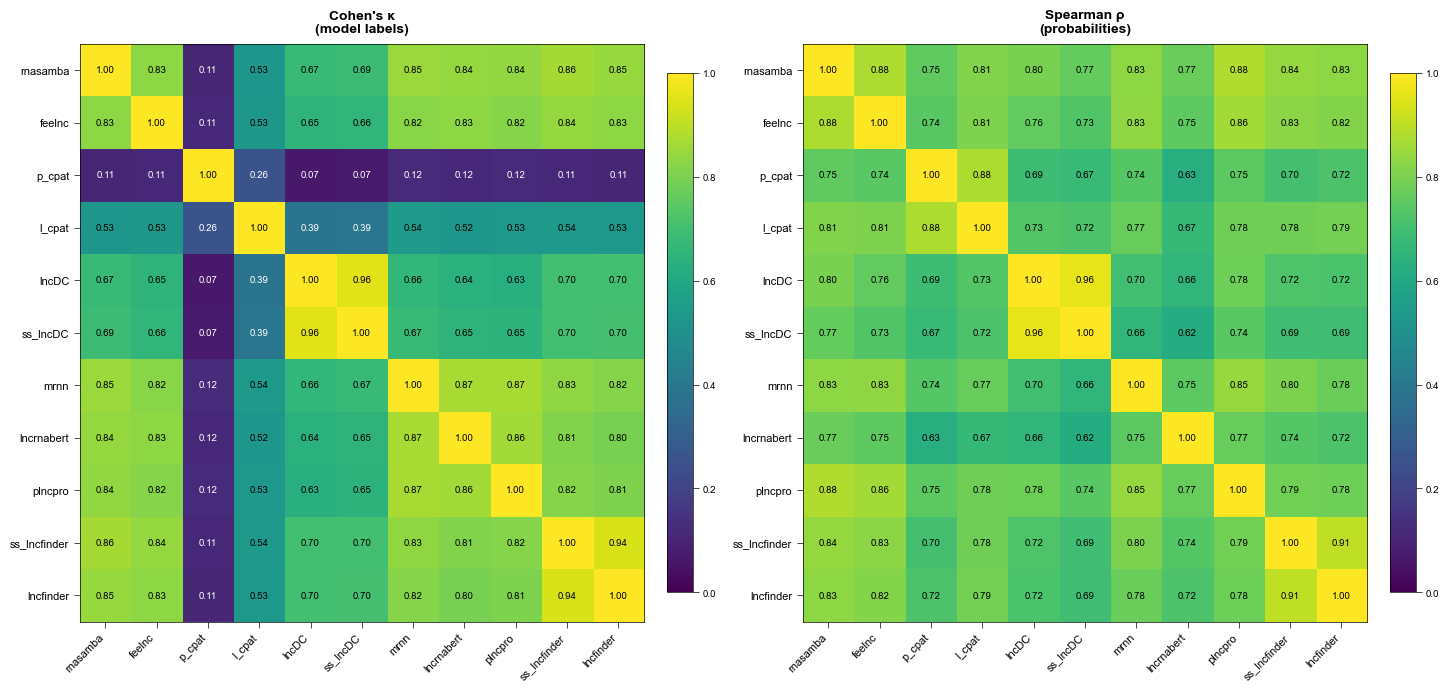

In [ ]:
# ── Cohen's Kappa (hard labels) ──────────────────────────────
tool_names = [c for c in binary_raw.columns if c not in ["fold", "real"]]
kappa_mat = generate_kappa_matrix(binary_raw, tool_names)

# ── Spearman ρ (probabilities) ────────────────────────────────────────────────
spearman_mat = generate_spearman_matrix(all_probs, tool_names)

print("Cohen's κ — pairwise hard-label agreement:")
display(kappa_mat.round(3))
print("\nSpearman ρ — pairwise probability correlation:")
display(spearman_mat.round(3))

save_table(kappa_mat.round(4),    TABLE_DIR / "T6a_cohen_kappa.tsv")
save_table(spearman_mat.round(4), TABLE_DIR / "T6b_spearman_rho.tsv")

# ── Heatmaps ──────────────────────────────────────────────────────────────────
def _agreement_heatmap(ax, mat, title, cmap, vmin, vmax, fmt=".2f"):
    n = len(mat)
    im = ax.imshow(mat.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(n)); ax.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(n)); ax.set_yticklabels(mat.index, fontsize=8)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)
    # annotate cells
    mid = (vmin + vmax) / 2
    for r in range(n):
        for c in range(n):
            v = mat.iloc[r, c]
            color = "white" if v < mid else "black"
            ax.text(c, r, format(v, fmt), ha="center", va="center", fontsize=7, color=color)
    return im

n_tools = len(tools)
fig, axes = plt.subplots(1, 2, figsize=(max(6, n_tools * 0.9) * 2, max(5, n_tools * 0.85)))

im1 = _agreement_heatmap(axes[0], kappa_mat,    "Cohen's κ\n(model labels)", "viridis", 0, 1)
im2 = _agreement_heatmap(axes[1], spearman_mat, "Spearman ρ\n(probabilities)",        "viridis", 0, 1)

for ax, im in zip(axes, [im1, im2]):
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

#fig.tight_layout()

plt.rcParams.update({
    "font.family": "Arial",
    "pdf.fonttype": 42,
})

for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"T6_agreement_heatmaps.{ext}", dpi=300, bbox_inches="tight")

fig

---
## Export — Combined XLSX Workbook

In [ ]:
tables = {
    "T1_CV_Metrics":        t1,
    "T2_BalancedAcc_Folds": t2,
    "T5_Calibration":       t5,
}
readme = {
    "T1_CV_Metrics":        "Full cross-validation metrics (long format): one row per fold x tool.",
    "T2_BalancedAcc_Folds": "Balanced accuracy per fold and tool (wide format), with mean and std.",
    "T5_Calibration":       "ECE, MCE, and over/under-confidence bin counts per tool (10-bin adaptive).",
}

if shap_available:
    tables["T3_SHAP_Importance"] = t3
    tables["T3b_SHAP_Per_Fold"]  = t3b
    readme["T3_SHAP_Importance"] = "Mean |SHAP value| +/- std for all features (sorted descending)."
    readme["T3b_SHAP_Per_Fold"]  = "Per-fold mean |SHAP value| for all features (wide format)."

if entropy_available:
    tables["T4a_MWU_Tests"]  = t4_mannu
    tables["T4b_Chi2_Tests"] = t4_chi2
    readme["T4a_MWU_Tests"]  = "Mann-Whitney U results for continuous features: low vs high entropy transcripts."
    readme["T4b_Chi2_Tests"] = "Chi-squared results for categorical features: low vs high entropy transcripts."

build_supplementary_workbook(
    tables,
    TABLE_DIR / "Supplementary_Tables_Classifier.xlsx",
    readme=readme,
)

NameError: name 't4_mannu' is not defined

---
## Summary

In [ ]:
print("=" * 70)
print("SUPPLEMENTARY OUTPUT SUMMARY")
print("=" * 70)

print("\nTables:")
for p in sorted(TABLE_DIR.glob("*.tsv")):
    rows = sum(1 for _ in open(p)) - 1
    print(f"  {p.name:<50s}  {rows:>6,} rows")

xlsx = TABLE_DIR / "Supplementary_Tables_Classifier.xlsx"
if xlsx.exists():
    print(f"  {xlsx.name:<50s}  {xlsx.stat().st_size/1024:.1f} KB")

print("\nFigures:")
for p in sorted(FIG_DIR.glob("*.pdf")):
    print(f"  {p.name}")